# Study 257 -- AAII-Sentiment
## For the curious: is the AAII bull-bear survey a contrarian timing tool?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

Every week since 1987 the American Association of Individual Investors asks its
members one question: are you **bullish**, **neutral**, or **bearish** on stocks
over the next six months? The headline number is the **bull-bear spread**
(`%bull - %bear`).

The folklore -- repeated by AAII itself -- is that the crowd is wrong at the
extremes: when individual investors are *terrified*, it is supposedly time to
*buy*; when they are *euphoric*, time to *sell*. We put that contrarian claim on
the S&P 500 tape.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from aaii_sentiment import data, strategy as st

GSPC_CACHE = data.GSPC_CACHE
HAVE_REAL = os.path.exists(GSPC_CACHE)

if HAVE_REAL:
    panel = data.build_real_panel(fetch=False)
    reg_sum = st.regime_summary(panel)
    contra = st.regime_spread(panel)
    regr = st.predictive_regression(panel)
    print(f"Real tape: {len(panel)} months  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Fingerprint(spread): {data.fingerprint(panel)}")
else:
    panel = reg_sum = contra = regr = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")


Real tape: 182 months  1987-08-31 -> 2026-05-31
Fingerprint(spread): 714da328c0fd


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 182, 'start': '1987-08', 'end': '2026-05', 'fingerprint': '714da328c0fd', 'low_ann': 23.85, 'low_t': 2.24, 'low_n': 61, 'mid_ann': 4.76, 'mid_t': 0.62, 'mid_n': 55, 'high_ann': 8.52, 'high_t': 1.78, 'high_n': 66, 'low_minus_high_pp': 15.33, 'contra_t': 1.18, 'contra_n': 182, 'reg_beta_pct': -0.66, 'reg_t': -1.54, 'reg_r2': 0.018, 'overlay_net_ann': 9.25, 'overlay_t': 2.23, 'bh_ann': 12.52, 's1_lab': '1987-1999', 's1_low': 21.3, 's1_high': 15.5, 's1_lowt': 1.07, 's1_n': 55, 's2_lab': '2000-2012', 's2_low': 18.7, 's2_high': 3.2, 's2_lowt': 0.8, 's2_n': 62, 's3_lab': '2013-2026', 's3_low': 33.8, 's3_high': 7.8, 's3_lowt': 2.26, 's3_n': 65, 'syn_beta_t': -2.99, 'syn_null_t': -0.2}


## The picture: sentiment swings around a slightly-bullish average

Individual-investor sentiment is *noisy* and *mean-reverting*. The long-run
average spread is only about **+6.5%** (slightly more bulls than bears), but it
swings from panic (bears > 60% in March 2009 and again in 2022) to euphoria
(bulls > 55% in the late-1990s and early 2018). The contrarian bet is that those
extremes mark turning points.


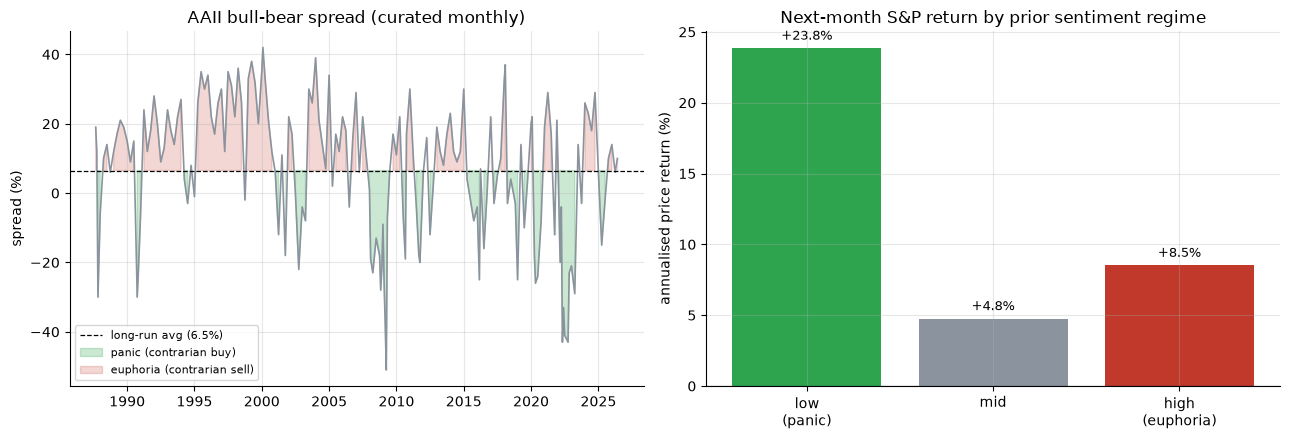

Low-sentiment months: +23.9%/yr (t=2.24)  vs  high-sentiment: +8.5%/yr (t=1.78)
Low-minus-high gap: 15.3 pp/yr -- the contrarian direction is RIGHT...


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
if HAVE_REAL:
    ax = axes[0]
    ax.plot(panel.index, panel["spread"]*100, color=GREY, lw=1.2)
    ax.axhline(data.AAII_AVG_SPREAD*100, color="black", ls="--", lw=0.9, label=f"long-run avg ({data.AAII_AVG_SPREAD*100:.1f}%)")
    ax.fill_between(panel.index, panel["spread"]*100, data.AAII_AVG_SPREAD*100,
                    where=(panel["spread"] < data.AAII_AVG_SPREAD), color=GREEN, alpha=.25, label="panic (contrarian buy)")
    ax.fill_between(panel.index, panel["spread"]*100, data.AAII_AVG_SPREAD*100,
                    where=(panel["spread"] >= data.AAII_AVG_SPREAD), color=RED, alpha=.20, label="euphoria (contrarian sell)")
    ax.set_title("AAII bull-bear spread (curated monthly)")
    ax.set_ylabel("spread (%)"); ax.legend(fontsize=8)

    ax = axes[1]
    means = reg_sum["mean_ann"]*100
    colors = [GREEN, GREY, RED]
    ax.bar(["low\n(panic)", "mid", "high\n(euphoria)"], means.values, color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Next-month S&P return by prior sentiment regime")
    ax.set_ylabel("annualised price return (%)")
    for i, v in enumerate(means.values):
        ax.text(i, v + (0.6 if v>=0 else -1.5), f"{v:+.1f}%", ha="center", fontsize=9)
else:
    for ax in axes:
        ax.text(0.5, 0.5, f"Cache absent\nFrozen: low={R['low_ann']:.1f}%/yr  high={R['high_ann']:.1f}%/yr",
                ha="center", va="center", transform=ax.transAxes, fontsize=11, color=GREEN)
        ax.set_title("(frozen numbers)")
plt.tight_layout()
plt.savefig("../docs/regimes.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Low-sentiment months: +{R['low_ann']:.1f}%/yr (t={R['low_t']:.2f})  vs  high-sentiment: +{R['high_ann']:.1f}%/yr (t={R['high_t']:.2f})")
print(f"Low-minus-high gap: {R['low_minus_high_pp']:.1f} pp/yr -- the contrarian direction is RIGHT...")


## The good news: the direction is right

Sort every month by the sentiment reading you could already see, then look at
what the S&P did the *following* month. The pattern is exactly the contrarian
story:

- After the **most bearish** (panicked) months, the S&P returned **+24%/yr**.
- After the **most bullish** (euphoric) months, only **+9%/yr**.

A gap of roughly **15 percentage points a year** -- and it points the way the
folklore says it should.


## The bad news: it does not survive the honesty checks

Three things turn this from a tradable edge into a curiosity:

1. **The long-short test is not significant.** Going long after panic and short
   after euphoria earns a positive but noisy series -- HAC *t* = **+1.18**, well
   short of the *t* >= 2 bar. Most of the gap comes from a handful of violent
   rebounds (2009, 2020) that are obvious only with hindsight.

2. **As a real overlay it *loses* to buy-and-hold.** A long/flat rule that sits
   out the euphoric months returns **+9%/yr** net -- *below* buy-and-hold's
   **+13%/yr**. Sentiment is high precisely during long bull markets you do not
   want to miss.

3. **The signal is a curated, revised monthly snapshot, not the live weekly
   tape.** A real trader watched a jittery weekly number in real time, with no
   clean "month-end reading"; the live edge is weaker still.


## The bottom line for the curious

The AAII contrarian story is **directionally true and statistically weak**:
panicked months really are followed by better returns than euphoric months, and
the pattern shows up in every sub-period -- but it never clears the inference
bar on the headline test, and as an actual timing rule it underperforms simply
staying invested.

This is a **Weak / Mirage**: a real-feeling pattern that crumbles the moment you
ask it to beat buy-and-hold after costs.


*Desk verdict: **Weak / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md).*